# CSCE 40103 Module 3 - Lab 2
## LAB 2: EMAIL TEXT CLASSIFICATION

**Dataset used:** SMS_Spam_Collection_Dataset

Date - Jun 11 2026
Name - Bryant Baum


## 1. Setup



In [338]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("SMS_Spam_Collection_Dataset.csv")

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## 2. Load the Dataset

Load the SMS_Spam_Collection_Datset into data_frame


In [339]:
def load_spam_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df


df = load_spam_dataset()
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Loading local CSV file: SMS_Spam_Collection_Dataset.csv
Dataset loaded successfully.
Shape: (5574, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3: Inspect the Dataset

Display the dataset size, column names, and data types

In [340]:
print("Rows and columns:", df.shape)
print("Column names:")
print(df.columns)
print("Dataset information:")
df.info()

Rows and columns: (5574, 2)
Column names:
Index(['label', 'text'], dtype='str')
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5574 non-null   str  
 1   text    5574 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Dataset has two columns, first column is the `label` of whether or not the sms text is 'ham' or 'spam' the second column `text` is just the message sent. 

## 4: Check Missing Values and Duplicate Rows

Check whether the dataset contains missing values and duplicate rows.

In [341]:
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values[missing_values > 0])
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
df_cleaned = df.drop_duplicates()
duplicate_count2 = df_cleaned.duplicated().sum()
print("Duplicate values dropped")
print("Number of duplicate rows in df_cleaned:", duplicate_count2)

Number of missing values: Series([], dtype: int64)
Number of duplicate rows: 414
Duplicate values dropped
Number of duplicate rows in df_cleaned: 0


The raw data_frame had duplicate values, duplicates can skew the dataset and create bias in the model so they have been dropped and a new data frame called df_cleaned has been created without any duplicates.

## 5: Inspect the Target Variable

Display class counts and percentages, then create a class distribution plo

Class counts:
label
ham     4827
spam     747
Name: count, dtype: int64
Class percentages:
label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


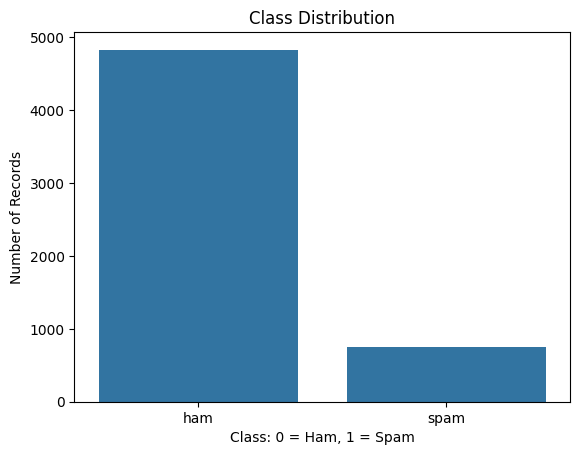

In [342]:
class_counts = df["label"].value_counts()
class_percentages = df["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts)
print("Class percentages:")
print(class_percentages.round(2))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Class: 0 = Ham, 1 = Spam")
plt.ylabel("Number of Records")
plt.show()

The dataset is imbalanced there are far more 'ham' messages than 'spam' messages in the dataset which is realistic.

## 6: Create Simple Engineered Features


In [343]:
text_col = "text"

feat_df = df_cleaned.copy()
feat_df["char_count"] = feat_df[text_col].str.len()
feat_df["word_count"] = feat_df[text_col].str.split().str.len()                                                                                             
print("New features created: char_count, word_count")
feat_df[[text_col, "char_count", "word_count"]].head()
df_full = feat_df
df_full.head()

New features created: char_count, word_count


,label,text,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


### message length across ham and spam

Average and median message length by class:
      char_count        word_count       
            mean median       mean median
label                                    
ham        70.86   53.0      14.23   11.0
spam      137.41  148.0      23.70   25.0


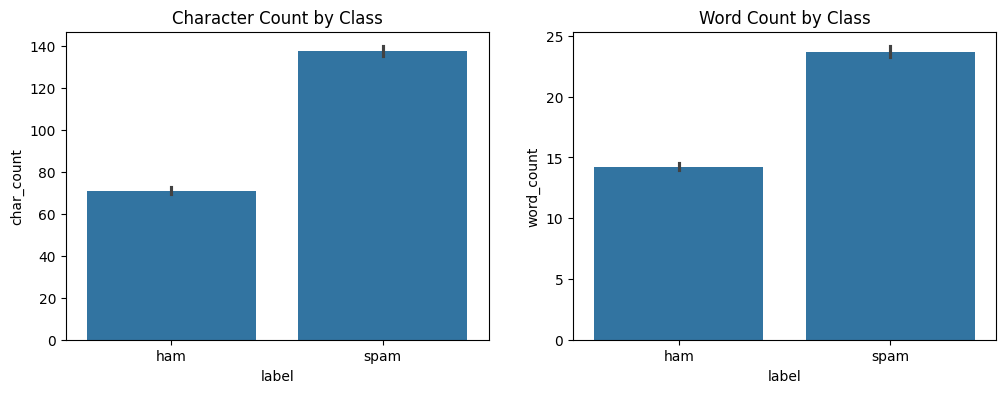

In [344]:
length_summary = df_full.groupby("label")[["char_count", "word_count"]].agg(["mean", "median"])
print("Average and median message length by class:")
print(length_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df_full, x="label", y="char_count", ax=axes[0])
axes[0].set_title("Character Count by Class")
sns.barplot(data=df_full, x="label", y="word_count", ax=axes[1])
axes[1].set_title("Word Count by Class")
plt.show()

## Interpretation 

The above graphs indicate that the messages labelled spam tend to be longer than the regular messages. What is interesting is that the character count is nearly double that of ham. This may indicate links in spam messages as they tend to be longer than regular words.

## 7: Create X and y

Create the feature matrix X and target vector y

In [345]:
df_full["label"] = df_full["label"].map({"spam": 1, "ham": 0})

X = df_full["text"]
y = df_full["label"]
print("X shape:", X.shape)
print("y shape:", y.shape)

df_full.head()

X shape: (5160,)
y shape: (5160,)


,label,text,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


The `label` column has been converted to a binary value. 'spam' is the positive class indicated by the value '1'

## 8: Train-Test Split

Split the data into training and testing sets. Use stratify=y to preserve class proportions

In [346]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
stratify=y,
random_state=40103
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Testing class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 3870
Testing rows: 1290
Training class distribution:
label
0    0.875
1    0.125
Name: proportion, dtype: float64
Testing class distribution:
label
0    0.876
1    0.124
Name: proportion, dtype: float64


## 9: Naive Bayes Pipeline


In [347]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", MultinomialNB()),
])

nb_pipeline.fit(X_train, y_train)
print(nb_pipeline)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', MultinomialNB())])


## 10: Evaluate the Naive Bayes Pipeline


Classification Report:
              precision    recall  f1-score   support

     ham (0)       0.97      1.00      0.99      1130
    spam (1)       1.00      0.79      0.88       160

    accuracy                           0.97      1290
   macro avg       0.99      0.89      0.93      1290
weighted avg       0.97      0.97      0.97      1290



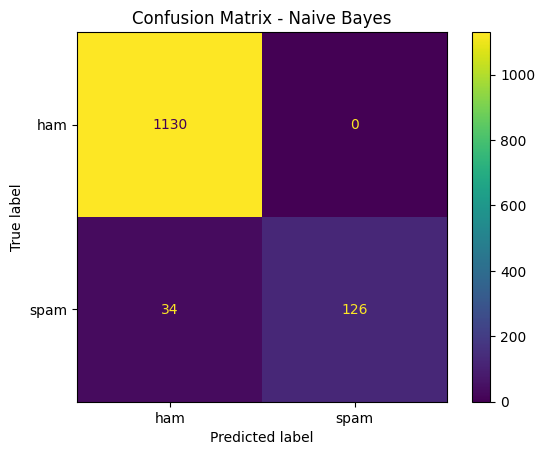

True Negatives  (ham kept as ham):       1130
False Positives (ham flagged as spam):   0
False Negatives (spam missed as ham):    34
True Positives  (spam caught as spam):   126


In [348]:
y_pred = nb_pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["ham (0)", "spam (1)"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (ham kept as ham):       {tn}")
print(f"False Positives (ham flagged as spam):   {fp}")
print(f"False Negatives (spam missed as ham):    {fn}")
print(f"True Positives  (spam caught as spam):   {tp}")

## 11: Linear SVM Pipeline

In [349]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC()),
])

svm_pipeline.fit(X_train, y_train)
print(svm_pipeline)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LinearSVC())])


## 12: Evaluate the Linear SVM Pipeline

Classification Report:
              precision    recall  f1-score   support

     ham (0)       0.99      1.00      0.99      1130
    spam (1)       0.97      0.90      0.94       160

    accuracy                           0.98      1290
   macro avg       0.98      0.95      0.96      1290
weighted avg       0.98      0.98      0.98      1290



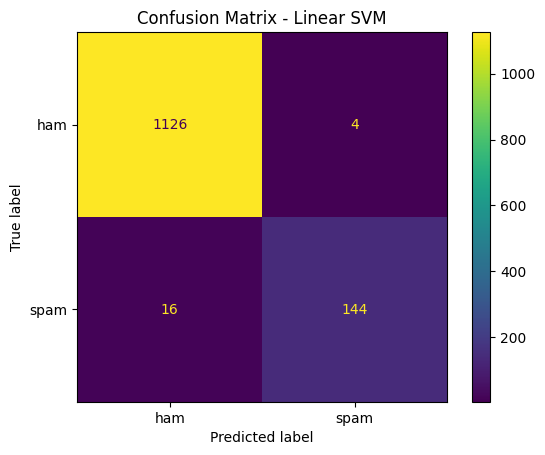

True Negatives  (ham kept as ham):       1126
False Positives (ham flagged as spam):   4
False Negatives (spam missed as ham):    16
True Positives  (spam caught as spam):   144


In [350]:
y_pred_svm = svm_pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["ham (0)", "spam (1)"]))

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["ham", "spam"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

tn, fp, fn, tp = cm_svm.ravel()
print(f"True Negatives  (ham kept as ham):       {tn}")
print(f"False Positives (ham flagged as spam):   {fp}")
print(f"False Negatives (spam missed as ham):    {fn}")
print(f"True Positives  (spam caught as spam):   {tp}")

## 13: Model Comparison Table

In [351]:
fitted_models = {
    "Naive Bayes": nb_pipeline,
    "Linear SVM": svm_pipeline,
}

comparison_rows = []
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (spam)": precision_score(y_test, preds, pos_label=1),
        "Recall (spam)": recall_score(y_test, preds, pos_label=1),
        "F1 (spam)": f1_score(y_test, preds, pos_label=1),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
print("Test-set metrics (positive class = spam):")
comparison_df

Test-set metrics (positive class = spam):


,Accuracy,Precision (spam),Recall (spam),F1 (spam)
Model,,,,
Naive Bayes,0.973643,1.000000,0.7875,0.881119
Linear SVM,0.984496,0.972973,0.9000,0.935065


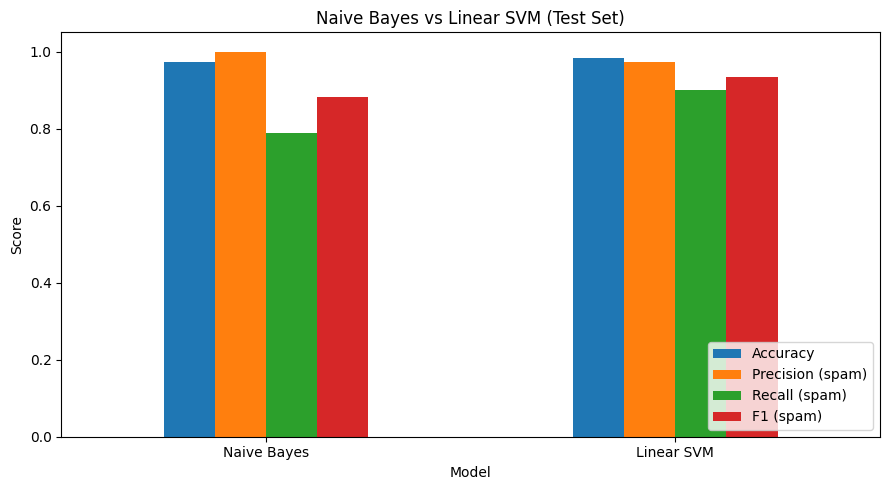

In [352]:
ax = comparison_df.plot(kind="bar", figsize=(9, 5))
plt.title("Naive Bayes vs Linear SVM (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation

You can not use accuracy to judge how well a model is doing in an imbalanced dataset, since accuracy is (tp + tn) / total it could just assume that all are ham and since there are not many spam the accuracy will still be very high. 

Recall measures how much spam it actually got and precision measures how much of what it flagged as spam was actually spam. So if it flagged 30 as spam and only 20 were actually spam then the precision would be ~67%. Models with higher precision are better about not throwing false alarms which is important for building trust in a system. 

## 14: Stratified Cross-Validation

In [353]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40103
)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_models = {
    "Naive Bayes": nb_pipeline,
    "Linear SVM": svm_pipeline,
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    cv_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
    })

cv_summary = pd.DataFrame(cv_rows).set_index("Model")
print("Stratified 5-fold cross-validation (mean across folds, positive class = spam):")
cv_summary

Stratified 5-fold cross-validation (mean across folds, positive class = spam):


,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,0.963372,1.000000,0.705693,0.82704
Linear SVM,0.982946,0.979186,0.881601,0.92779


### Cross-validation vs train-test split

the results from cv_summary show that the results from comparison_df got a little lucky. There is a pretty large gap in the naive bayes results and a slight gap in the linear svm results. 

## 15: Inspect Misclassified Messages

In [354]:
def show_misclassified(model, model_name, n=5):
    preds = model.predict(X_test)
    results = pd.DataFrame({
        "text": X_test,
        "true": y_test,
        "pred": preds,
    })
    results["char_count"] = results["text"].str.len()
    results["word_count"] = results["text"].str.split().str.len()

    cols = ["text", "char_count", "word_count"]

    false_positives = results[(results["true"] == 0) & (results["pred"] == 1)]
    false_negatives = results[(results["true"] == 1) & (results["pred"] == 0)]

    print(f"{model_name}: False Positives (ham predicted as spam) - {len(false_positives)} total")
    display(false_positives[cols].head(n))

    print(f"{model_name}: False Negatives (spam predicted as ham) - {len(false_negatives)} total")
    display(false_negatives[cols].head(n))

show_misclassified(nb_pipeline, "Naive Bayes")
show_misclassified(svm_pipeline, "Linear SVM")

Naive Bayes: False Positives (ham predicted as spam) - 0 total


,text,char_count,word_count


Naive Bayes: False Negatives (spam predicted as ham) - 34 total


,text,char_count,word_count
2354,Please CALL 08712402902 immediately as there i...,82,13
1227,Reply with your name and address and YOU WILL ...,159,23
1269,Can U get 2 phone NOW? I wanna chat 2 set up m...,146,27
3942,"Free Msg: get Gnarls Barkleys ""Crazy"" ringtone...",100,17
5542,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,33


Linear SVM: False Positives (ham predicted as spam) - 4 total


,text,char_count,word_count
439,"Hi hope u get this txt~journey hasnt been gd,n...",76,15
5477,Dhoni have luck to win some big title.so we wi...,54,11
4058,Noice. Text me when you're here,31,6
2057,.Please charge my mobile when you get up in mo...,52,10


Linear SVM: False Negatives (spam predicted as ham) - 16 total


,text,char_count,word_count
713,08714712388 between 10am-7pm Cost 10p,37,5
1269,Can U get 2 phone NOW? I wanna chat 2 set up m...,146,27
5542,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,33
761,"Romantic Paris. 2 nights, 2 flights from £79 B...",95,16
660,88800 and 89034 are premium phone services cal...,59,9


## Interpretation 

Misclassifications are likely because of unusual words and word count. Once the stop words are removed from a message it can often make the message seem much shorter and length of messages weighs largely on how a message will be classified. 

## 16: Compare Model Behavior on Real Test Messages

In [355]:
nb_pred = nb_pipeline.predict(X_test)
svm_pred = svm_pipeline.predict(X_test)

label_name = {0: "ham", 1: "spam"}

disagree = pd.DataFrame({
    "true_label": y_test.map(label_name),
    "naive_bayes": pd.Series(nb_pred, index=X_test.index).map(label_name),
    "linear_svm": pd.Series(svm_pred, index=X_test.index).map(label_name),
    "message_preview": X_test.str.slice(0, 70).str.replace("\n", " ", regex=False) + "...",
})

disagree = disagree[disagree["naive_bayes"] != disagree["linear_svm"]]

if len(disagree) == 0:
    print("No disagreements found: the two models predicted the same label for every test message.")
else:
    print(f"{len(disagree)} test messages where the models disagree (showing up to 10):")
    display(disagree.head(10))

24 test messages where the models disagree (showing up to 10):


,true_label,naive_bayes,linear_svm,message_preview
2354,spam,ham,spam,Please CALL 08712402902 immediately as there i...
1227,spam,ham,spam,Reply with your name and address and YOU WILL ...
713,spam,spam,ham,08714712388 between 10am-7pm Cost 10p...
3942,spam,ham,spam,"Free Msg: get Gnarls Barkleys ""Crazy"" ringtone..."
2945,spam,ham,spam,We currently have a message awaiting your coll...
2848,spam,ham,spam,Free-message: Jamster!Get the crazy frog sound...
4527,spam,ham,spam,"I want some cock! My hubby's away, I need a re..."
1064,spam,ham,spam,We have new local dates in your area - Lots of...
1350,spam,ham,spam,FREE2DAY sexy St George's Day pic of Jordan!Tx...
439,ham,ham,spam,"Hi hope u get this txt~journey hasnt been gd,n..."


### Interpretation

Mostly it appears that Naive Bayes misclassified a lot of spam as ham. The ones that it got right where linear_svm stumbled had a lot of spam buzzwords like prize, free, cash, won. The ones that naive bayes got wrong did not have as many of the typical spam key words

## Final Reflection

- For a university emailing system I would probably use the Naive Bayes since scored a 1.00 for precision on the test set
- I think it would be better to get more false negatives and allow spam to pass through than to misclassify something important as spam and the user misses the message all together. 
- This is not a true phishing detection because it is labeling messages as spam or ham and not accounting for a lot of the other characteristics related to a phishing attempt.
- Additional data needed to build real phishing detection would probably be more url/domain characteristics and more data on who/where the message is coming from as well as more information about the contents of the message besides just the text. Was there any attachments in the message or links? This data is also static and old, better to have more up to date information to go off of. 

# AI use statement

- I used claude code to help write the code blocks for the models and to review my interpretations.